### Import ###

In [60]:
import pandas as pd
import os
import math
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
import random
import re

In [52]:
# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

# Specify the directory and filename
save_dir = "./Images/"

In [24]:
import import_ipynb
from derived_classes import AnySecDataProcessor

## Compressing Study Data by any Seconds
#### The smartest option is 0.1, since it then can be merged to make any other portion, 0.2, ... 0.9 sec.

In [27]:
def split_into_chunks(df, groupby_column, num_chunks):
    # Group the data
    grouped_data = df.groupby(groupby_column)
    
    # Function to split each group into equal-sized chunks
    def split_group(group):
        chunk_size = len(group) // num_chunks
        labels = [i for i in range(1, num_chunks + 1) for _ in range(chunk_size)]
        remainder = len(group) % num_chunks
        labels += [num_chunks] * remainder
        group['quantile'] = labels[:len(group)]
        return group
    # Apply the function to each group and concatenate the results
    result = grouped_data.apply(split_group)
    
    return result.reset_index(drop=True)
    
# Ask the user for the time duration to turn it into the number of chunks
x = float(input("Enter the segment size in seconds (e.g., 0.2): "))
quantile = int(1/x)
# type(quantile)

Enter the segment size in seconds (e.g., 0.2):  0.1


In [32]:
data_by_sec = pd.DataFrame()

# Get the current working directory
current_directory = os.getcwd()

# Specify the relative folder path
folder_path = os.path.join(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code", 'textfiles')

In [63]:
#MAB    
# Loop over all files in the folder
# Specify the specific file name you want to read
file_name = 'PID_046_Low_2024-8-26_16_55_4'

# Construct the full path to the specific file
file_path = os.path.join(folder_path, file_name)
df = pd.read_csv(file_path, header=None, names=['line'])

# Split the filename
print(file_name)
data_line = file_name.split('_')
print(data_line[1:7])

# Find the start and end index for each AGV
prefix_range = range(1, 17)
prefix_list = list(f"{'AGVname=AGV'}{x}" for x in prefix_range)
start_ind = []
for prefix in prefix_list:
    matching_indices = df[df['line'].str.startswith(prefix)].index
    if not matching_indices.empty:
        start_ind.append(matching_indices[0])
    else:
        # Handle the case where no match is found
        print(f"No match found for prefix: {prefix}")
        start_ind.append(None)  # or handle it in another appropriate way

end_ind = df[df['line'].str.startswith('CheckPoint/Route')].index

user_data = pd.DataFrame(columns=['User_X', 'User_Y', 'User_Z', 'Timestamp', 'User_Pitch', 'User_Yaw', 'User_Roll', 'U_X', 'U_Y', 'U_Z','quantile'])
gaze_data = pd.DataFrame(columns=['Target', 'Timestamp', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z','GazeDirection_X','GazeDirection_Y','GazeDirection_Z','Confidence','quantile'])
AGV_data = pd.DataFrame(columns=['AGVname', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd', 'Timestamp','quantile'])
    
for i in range(16):
    print(f"Processing index: {i}")
    print(f"start_ind[{i}] = {start_ind[i]}")
    print(f"end_ind[{i}] = {end_ind[i]}")
    
    # Check if the indices are not None
    if start_ind[i] is not None and end_ind[i] is not None:
        for j in range(start_ind[i], end_ind[i]):
            line = df['line'].iloc[j]

            if line[0] == 'U':
                fields = line.split()
                d = []
                for field in fields:
                    parts = field.split('=')
                    key, value = parts
                    d.append(value)
                user_data.loc[len(user_data)] = d
                #print(d)
            elif line[0] == 'E':
                fields = line.split()
                d = []
                for field in fields:
                    parts = field.split('=')
                    key, value = parts
                    d.append(value)
                gaze_data.loc[len(gaze_data)] = d
                #print(d)
            elif line[0] == 'A':
                fields = line.split()
                d = []
                for field in fields:
                    parts = field.split('=')
                    key, value = parts
                    d.append(value)
                AGV_data.loc[len(AGV_data)] = d
                #print(d)
    else:
        # if an AGV data is not recorded, this message will appear and processing the data for that will be skipped
        print(f"Skipping index {i} due to None value in start_ind or end_ind")
            #print(d)
    print('number of quantiles based on the sec entry:', quantile)
    user_data = user_data.astype({'User_X':float, 'User_Y':float, 'User_Z':float, 'User_Pitch':float, 'User_Yaw':float, 'User_Roll':float, 'U_X':float, 'U_Y':float, 'U_Z':float})
    user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'], format='%H:%M:%S').dt.time
    user_data['quantile'] = quantile
    # Call the function to split the data into the specified number of chunks based on Timestamp, and add the chunk lable as an indicator
    user_data = split_into_chunks(user_data, 'Timestamp', quantile)
    # Calculate the mean of the user_data columns for each unique pair of quntile and timestamp
    grouped_user = user_data.groupby(['Timestamp', 'quantile']).mean().reset_index()
    user_data.drop(columns=['quantile'], inplace=True)
    print('user_data done for AGV', i+1)
    
    gaze_data = gaze_data.astype({'GazeOrigin_X':float, 'GazeOrigin_Y':float, 'GazeOrigin_Z':float, 'GazeDirection_X':float, 'GazeDirection_Y':float,'GazeDirection_Z':float, 'Confidence':float})
    gaze_data['Timestamp'] = pd.to_datetime(gaze_data['Timestamp'], format='%H:%M:%S').dt.time
    # Call the function to split the gaze_data into the specified number of chunks based on Timestamp, and add the chunk lable as an indicator
    gaze_data = split_into_chunks(gaze_data, 'Timestamp', quantile)
    # Calculate the mean of the gaze_data columns for each unique pair of quntile and timestamp
    grouped_gaze = gaze_data.groupby(['Timestamp', 'quantile'])[['GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z','GazeDirection_X','GazeDirection_Y','GazeDirection_Z','Confidence']].mean().reset_index()
    starts_with_agv = gaze_data.groupby(['Timestamp', 'quantile'])['Target'].apply(lambda x: any(s.startswith('AGV') for s in x.values)).reset_index(name='Gaze_on_AGV')
    grouped_gaze = pd.merge(grouped_gaze, starts_with_agv, on=['Timestamp', 'quantile'])
    gaze_data.drop(columns=['quantile'], inplace=True)
    print('gaze_data done for AGV', i+1)
    
    AGV_data = AGV_data.astype({'AGV_X':float, 'AGV_Y':float, 'AGV_Z':float, 'AGV_Pitch':float, 'AGV_Yaw':float, 'AGV_Roll':float,'AGV_spd':float})
    AGV_data['Timestamp'] = pd.to_datetime(AGV_data['Timestamp'], format='%H:%M:%S').dt.time
    AGV_data = split_into_chunks(AGV_data, 'Timestamp', quantile)
    grouped_agv = AGV_data.groupby(['Timestamp', 'quantile'])[['AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd']].mean().reset_index()
    majority_df = AGV_data.groupby(['Timestamp', 'quantile'])['AGVname'].apply(lambda x: x.mode().iloc[0]).reset_index(name='AGVname')
    grouped_agv = pd.merge(grouped_agv, majority_df, on=['Timestamp', 'quantile'])
    AGV_data.drop(columns=['quantile'], inplace=True)
    print('AGV_data done for AGV', i+1)
    
    merged_df = grouped_user.merge(grouped_gaze, on=['Timestamp', 'quantile']).merge(grouped_agv, on=['Timestamp', 'quantile'])
    print('Merging three parts of the dataset based on AGV', i+1)
    
    # Creating a DataFrame from the repeated random list
    PID_DRate_df = pd.DataFrame([data_line[1:3]] * len(merged_df), columns=['PID','DRate'])

    # Concatenating the original DataFrame with the additional columns
    final_df = pd.concat([merged_df, PID_DRate_df], axis=1)
    data_by_sec = pd.concat([data_by_sec, final_df], ignore_index=True)
    # Save the merged dataset to a new CSV file with a timestamp in the filename

PID_046_Low_2024-8-26_16_55_4
['046', 'Low', '2024-8-26', '16', '55', '4']
Processing index: 0
start_ind[0] = 24756
end_ind[0] = 23416
number of quantiles based on the sec entry: 10
user_data done for AGV 1
gaze_data done for AGV 1
AGV_data done for AGV 1
Merging three parts of the dataset based on AGV 1
Processing index: 1
start_ind[1] = 3058
end_ind[1] = 35113
number of quantiles based on the sec entry: 10
user_data done for AGV 2
gaze_data done for AGV 2
AGV_data done for AGV 2
Merging three parts of the dataset based on AGV 2
Processing index: 2
start_ind[2] = 35739
end_ind[2] = 48063
number of quantiles based on the sec entry: 10
user_data done for AGV 3
gaze_data done for AGV 3
AGV_data done for AGV 3
Merging three parts of the dataset based on AGV 3
Processing index: 3
start_ind[3] = 49166
end_ind[3] = 60387
number of quantiles based on the sec entry: 10
user_data done for AGV 4
gaze_data done for AGV 4
AGV_data done for AGV 4
Merging three parts of the dataset based on AGV 4
Pr

In [64]:
# Concatenating the new preprocessed DataFrame with ISU_data_by_0.1_sec by adding it to the end of the dataset
# Reading the main CSV file
main_data = pd.read_csv('ISU_data_by_0.1_sec.csv')

# Merging the new processed data with the main CSV file
merged_data = pd.concat([main_data, data_by_sec], axis=0)

# Print the merged data
print('After merging:')
print(merged_data)

# Generate a timestamp
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the merged dataset to a new CSV file with a timestamp in the filename
merged_data.to_csv(f'ISU_data_by_{x}_sec.csv', index=False)

After merging:
           User_X    User_Y   User_Z  User_Pitch   User_Yaw  User_Roll  \
0        5051.235  8610.830 -209.725  -21.416662 -92.196247  -0.159610   
1        5051.235  8610.830 -209.725  -21.168361 -92.384752   0.290698   
2        5051.235  8610.830 -209.725  -21.240655 -92.761660   0.339485   
3        5051.235  8610.830 -209.725  -21.004733 -93.120707   0.251285   
4        5051.235  8610.830 -209.725  -20.717933 -91.225685   0.512156   
...           ...       ...      ...         ...        ...        ...   
2652450  4814.045  8544.847 -209.725    9.361614 -83.257447   2.434928   
2652451  4814.045  8544.847 -209.725    8.837808 -85.161383   1.814595   
2652452  4814.045  8544.847 -209.725    8.142000 -88.676587   0.913597   
2652453  4814.045  8544.847 -209.725    7.388442 -92.010121   0.207441   
2652454  4814.045  8544.847 -209.725    6.817216 -95.838622  -0.021608   

               U_X         U_Y         U_Z  GazeOrigin_X  ...       AGV_Z  \
0        60.524000 

## Saving the 0.1 Sec Data into Two Splits

### First Half

In [10]:
# Get a list of all files in the specified folder (no specific extension check)
text_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Determine the midpoint to process only the first half of the files
half_index = len(text_files) // 2
files_to_process = text_files[:half_index]  # Adjust this to get only the first half

# Initialize an empty DataFrame to store combined results
data_by_sec = pd.DataFrame()

# Loop over all files in the first half
for file_name in files_to_process:
    # Construct the full path to the specific file
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, header=None, names=['line'])

    # Split the filename
    print(file_name)
    data_line = file_name.split('_')
    print(data_line[1:7])

    # Find the start and end index for each AGV
    prefix_range = range(1, 17)
    prefix_list = list(f"{'AGVname=AGV'}{x}" for x in prefix_range)
    start_ind = []
    for prefix in prefix_list:
        matching_indices = df[df['line'].str.startswith(prefix)].index
        if not matching_indices.empty:
            start_ind.append(matching_indices[0])
        else:
            print(f"No match found for prefix: {prefix}")
            start_ind.append(None)

    end_ind = df[df['line'].str.startswith('CheckPoint/Route')].index

    user_data = pd.DataFrame(columns=['User_X', 'User_Y', 'User_Z', 'Timestamp', 'User_Pitch', 'User_Yaw', 'User_Roll', 'U_X', 'U_Y', 'U_Z', 'quantile'])
    gaze_data = pd.DataFrame(columns=['Target', 'Timestamp', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z', 'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence', 'quantile'])
    AGV_data = pd.DataFrame(columns=['AGVname', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd', 'Timestamp', 'quantile'])

    for i in range(16):
        print(f"Processing index: {i}")
        print(f"start_ind[{i}] = {start_ind[i]}")
        print(f"end_ind[{i}] = {end_ind[i]}")

        if start_ind[i] is not None and end_ind[i] is not None:
            for j in range(start_ind[i], end_ind[i]):
                line = df['line'].iloc[j]

                if line[0] == 'U':
                    fields = line.split()
                    d = []
                    for field in fields:
                        parts = field.split('=')
                        key, value = parts
                        d.append(value)
                    user_data.loc[len(user_data)] = d
                elif line[0] == 'E':
                    fields = line.split()
                    d = []
                    for field in fields:
                        parts = field.split('=')
                        key, value = parts
                        d.append(value)
                    gaze_data.loc[len(gaze_data)] = d
                elif line[0] == 'A':
                    fields = line.split()
                    d = []
                    for field in fields:
                        parts = field.split('=')
                        key, value = parts
                        d.append(value)
                    AGV_data.loc[len(AGV_data)] = d
        else:
            print(f"Skipping index {i} due to None value in start_ind or end_ind")

        print('number of quantiles based on the sec entry:', quantile)
        user_data = user_data.astype({'User_X': float, 'User_Y': float, 'User_Z': float, 'User_Pitch': float, 'User_Yaw': float, 'User_Roll': float, 'U_X': float, 'U_Y': float, 'U_Z': float})
        user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'], format='%H:%M:%S').dt.time
        user_data['quantile'] = quantile
        user_data = split_into_chunks(user_data, 'Timestamp', quantile)
        grouped_user = user_data.groupby(['Timestamp', 'quantile']).mean().reset_index()
        user_data.drop(columns=['quantile'], inplace=True)
        print('user_data done for AGV', i + 1)

        gaze_data = gaze_data.astype({'GazeOrigin_X': float, 'GazeOrigin_Y': float, 'GazeOrigin_Z': float, 'GazeDirection_X': float, 'GazeDirection_Y': float, 'GazeDirection_Z': float, 'Confidence': float})
        gaze_data['Timestamp'] = pd.to_datetime(gaze_data['Timestamp'], format='%H:%M:%S').dt.time
        gaze_data = split_into_chunks(gaze_data, 'Timestamp', quantile)
        grouped_gaze = gaze_data.groupby(['Timestamp', 'quantile'])[['GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z', 'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence']].mean().reset_index()
        starts_with_agv = gaze_data.groupby(['Timestamp', 'quantile'])['Target'].apply(lambda x: any(s.startswith('AGV') for s in x.values)).reset_index(name='Gaze_on_AGV')
        grouped_gaze = pd.merge(grouped_gaze, starts_with_agv, on=['Timestamp', 'quantile'])
        gaze_data.drop(columns=['quantile'], inplace=True)
        print('gaze_data done for AGV', i + 1)

        AGV_data = AGV_data.astype({'AGV_X': float, 'AGV_Y': float, 'AGV_Z': float, 'AGV_Pitch': float, 'AGV_Yaw': float, 'AGV_Roll': float, 'AGV_spd': float})
        AGV_data['Timestamp'] = pd.to_datetime(AGV_data['Timestamp'], format='%H:%M:%S').dt.time
        AGV_data = split_into_chunks(AGV_data, 'Timestamp', quantile)
        grouped_agv = AGV_data.groupby(['Timestamp', 'quantile'])[['AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd']].mean().reset_index()
        majority_df = AGV_data.groupby(['Timestamp', 'quantile'])['AGVname'].apply(lambda x: x.mode().iloc[0]).reset_index(name='AGVname')
        grouped_agv = pd.merge(grouped_agv, majority_df, on=['Timestamp', 'quantile'])
        AGV_data.drop(columns=['quantile'], inplace=True)
        print('AGV_data done for AGV', i + 1)

        merged_df = grouped_user.merge(grouped_gaze, on=['Timestamp', 'quantile']).merge(grouped_agv, on=['Timestamp', 'quantile'])
        print('Merging three parts of the dataset based on AGV', i + 1)

        PID_DRate_df = pd.DataFrame([data_line[1:3]] * len(merged_df), columns=['PID', 'DRate'])
        final_df = pd.concat([merged_df, PID_DRate_df], axis=1)
        data_by_sec = pd.concat([data_by_sec, final_df], ignore_index=True)

PID_001_High_2024-5-3_14_28_53
['001', 'High', '2024-5-3', '14', '28', '53']
Processing index: 0
start_ind[0] = 14802
end_ind[0] = 12970
number of quantiles based on the sec entry: 10
user_data done for AGV 1
gaze_data done for AGV 1
AGV_data done for AGV 1
Merging three parts of the dataset based on AGV 1
Processing index: 1
start_ind[1] = 2331
end_ind[1] = 23719
number of quantiles based on the sec entry: 10
user_data done for AGV 2
gaze_data done for AGV 2
AGV_data done for AGV 2
Merging three parts of the dataset based on AGV 2
Processing index: 2
start_ind[2] = 25464
end_ind[2] = 37720
number of quantiles based on the sec entry: 10
user_data done for AGV 3
gaze_data done for AGV 3
AGV_data done for AGV 3
Merging three parts of the dataset based on AGV 3
Processing index: 3
start_ind[3] = 40188
end_ind[3] = 51158
number of quantiles based on the sec entry: 10
user_data done for AGV 4
gaze_data done for AGV 4
AGV_data done for AGV 4
Merging three parts of the dataset based on AGV 4


IndexError: index 14 is out of bounds for axis 0 with size 14

In [11]:
# Save the merged dataset to a new CSV file with a timestamp in the filename
data_by_sec.to_csv('ISU_data_first_half.csv', index=False)

print('Data processing complete. File saved as ISU_data_first_half.csv.')

Data processing complete. File saved as ISU_data_first_half.csv.


### Second Half

In [12]:
# Get a list of all files in the specified folder
text_files = sorted([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])

# Find the indices for the starting and ending files
start_file = 'PID_026_High_2024-8-12_14_51_30'
end_file = 'PID_046_Low_2024-8-26_16_55_4'

# Locate start and end indices in the list
start_index = text_files.index(start_file)
end_index = text_files.index(end_file) + 1  # Include the end file in processing

# Select files for processing (second half)
files_to_process = text_files[start_index:end_index]

# Initialize an empty DataFrame to store combined results
data_by_sec = pd.DataFrame()

# Loop over all files in the second half
for file_name in files_to_process:
    # Construct the full path to the specific file
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, header=None, names=['line'])

    # Split the filename
    print(file_name)
    data_line = file_name.split('_')
    print(data_line[1:7])

    # Find the start and end index for each AGV
    prefix_range = range(1, 17)
    prefix_list = list(f"{'AGVname=AGV'}{x}" for x in prefix_range)
    start_ind = []
    for prefix in prefix_list:
        matching_indices = df[df['line'].str.startswith(prefix)].index
        if not matching_indices.empty:
            start_ind.append(matching_indices[0])
        else:
            print(f"No match found for prefix: {prefix}")
            start_ind.append(None)

    end_ind = df[df['line'].str.startswith('CheckPoint/Route')].index

    user_data = pd.DataFrame(columns=['User_X', 'User_Y', 'User_Z', 'Timestamp', 'User_Pitch', 'User_Yaw', 'User_Roll', 'U_X', 'U_Y', 'U_Z', 'quantile'])
    gaze_data = pd.DataFrame(columns=['Target', 'Timestamp', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z', 'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence', 'quantile'])
    AGV_data = pd.DataFrame(columns=['AGVname', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd', 'Timestamp', 'quantile'])

    for i in range(16):
        print(f"Processing index: {i}")
        print(f"start_ind[{i}] = {start_ind[i]}")
        print(f"end_ind[{i}] = {end_ind[i]}")

        if start_ind[i] is not None and end_ind[i] is not None:
            for j in range(start_ind[i], end_ind[i]):
                line = df['line'].iloc[j]

                if line[0] == 'U':
                    fields = line.split()
                    d = []
                    for field in fields:
                        parts = field.split('=')
                        key, value = parts
                        d.append(value)
                    user_data.loc[len(user_data)] = d
                elif line[0] == 'E':
                    fields = line.split()
                    d = []
                    for field in fields:
                        parts = field.split('=')
                        key, value = parts
                        d.append(value)
                    gaze_data.loc[len(gaze_data)] = d
                elif line[0] == 'A':
                    fields = line.split()
                    d = []
                    for field in fields:
                        parts = field.split('=')
                        key, value = parts
                        d.append(value)
                    AGV_data.loc[len(AGV_data)] = d
        else:
            print(f"Skipping index {i} due to None value in start_ind or end_ind")

        print('number of quantiles based on the sec entry:', quantile)
        user_data = user_data.astype({'User_X': float, 'User_Y': float, 'User_Z': float, 'User_Pitch': float, 'User_Yaw': float, 'User_Roll': float, 'U_X': float, 'U_Y': float, 'U_Z': float})
        user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'], format='%H:%M:%S').dt.time
        user_data['quantile'] = quantile
        user_data = split_into_chunks(user_data, 'Timestamp', quantile)
        grouped_user = user_data.groupby(['Timestamp', 'quantile']).mean().reset_index()
        user_data.drop(columns=['quantile'], inplace=True)
        print('user_data done for AGV', i + 1)

        gaze_data = gaze_data.astype({'GazeOrigin_X': float, 'GazeOrigin_Y': float, 'GazeOrigin_Z': float, 'GazeDirection_X': float, 'GazeDirection_Y': float, 'GazeDirection_Z': float, 'Confidence': float})
        gaze_data['Timestamp'] = pd.to_datetime(gaze_data['Timestamp'], format='%H:%M:%S').dt.time
        gaze_data = split_into_chunks(gaze_data, 'Timestamp', quantile)
        grouped_gaze = gaze_data.groupby(['Timestamp', 'quantile'])[['GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z', 'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence']].mean().reset_index()
        starts_with_agv = gaze_data.groupby(['Timestamp', 'quantile'])['Target'].apply(lambda x: any(s.startswith('AGV') for s in x.values)).reset_index(name='Gaze_on_AGV')
        grouped_gaze = pd.merge(grouped_gaze, starts_with_agv, on=['Timestamp', 'quantile'])
        gaze_data.drop(columns=['quantile'], inplace=True)
        print('gaze_data done for AGV', i + 1)

        AGV_data = AGV_data.astype({'AGV_X': float, 'AGV_Y': float, 'AGV_Z': float, 'AGV_Pitch': float, 'AGV_Yaw': float, 'AGV_Roll': float, 'AGV_spd': float})
        AGV_data['Timestamp'] = pd.to_datetime(AGV_data['Timestamp'], format='%H:%M:%S').dt.time
        AGV_data = split_into_chunks(AGV_data, 'Timestamp', quantile)
        grouped_agv = AGV_data.groupby(['Timestamp', 'quantile'])[['AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd']].mean().reset_index()
        majority_df = AGV_data.groupby(['Timestamp', 'quantile'])['AGVname'].apply(lambda x: x.mode().iloc[0]).reset_index(name='AGVname')
        grouped_agv = pd.merge(grouped_agv, majority_df, on=['Timestamp', 'quantile'])
        AGV_data.drop(columns=['quantile'], inplace=True)
        print('AGV_data done for AGV', i + 1)

        merged_df = grouped_user.merge(grouped_gaze, on=['Timestamp', 'quantile']).merge(grouped_agv, on=['Timestamp', 'quantile'])
        print('Merging three parts of the dataset based on AGV', i + 1)

        PID_DRate_df = pd.DataFrame([data_line[1:3]] * len(merged_df), columns=['PID', 'DRate'])
        final_df = pd.concat([merged_df, PID_DRate_df], axis=1)
        data_by_sec = pd.concat([data_by_sec, final_df], ignore_index=True)

PID_026_High_2024-8-12_14_51_30
['026', 'High', '2024-8-12', '14', '51', '30']
Processing index: 0
start_ind[0] = 14201
end_ind[0] = 13272
number of quantiles based on the sec entry: 10
user_data done for AGV 1
gaze_data done for AGV 1
AGV_data done for AGV 1
Merging three parts of the dataset based on AGV 1
Processing index: 1
start_ind[1] = 2558
end_ind[1] = 21849
number of quantiles based on the sec entry: 10
user_data done for AGV 2
gaze_data done for AGV 2
AGV_data done for AGV 2
Merging three parts of the dataset based on AGV 2
Processing index: 2
start_ind[2] = 22793
end_ind[2] = 32941
number of quantiles based on the sec entry: 10
user_data done for AGV 3
gaze_data done for AGV 3
AGV_data done for AGV 3
Merging three parts of the dataset based on AGV 3
Processing index: 3
start_ind[3] = 34062
end_ind[3] = 41623
number of quantiles based on the sec entry: 10
user_data done for AGV 4
gaze_data done for AGV 4
AGV_data done for AGV 4
Merging three parts of the dataset based on AGV 

In [13]:
# Save the merged dataset to a new CSV file with a timestamp in the filename
data_by_sec.to_csv('ISU_data_second_half.csv', index=False)

print('Data processing complete. File saved as ISU_data_second_half.csv.')

Data processing complete. File saved as ISU_data_second_half.csv.


## Compressing Study Data by One Second

In [56]:
#Original 

# Loop over all files in the folder
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path, header=None, names=['line'])

    # Split the filenames
    print(filename)
    data_line = filename.split('_')
    print(data_line[1:3])

    # Find the start and end index for each AGV
    prefix_range = range(1, 17)
    prefix_list = list(f"{'AGVname=AGV'}{x}" for x in prefix_range)
    start_ind = []
    for prefix in prefix_list:
        start_ind.append(df[df['line'].str.startswith(prefix)].index[0])
    end_ind = df[df['line'].str.startswith('CheckPoint/Route')].index

    user_data = pd.DataFrame(columns=['User_X', 'User_Y', 'User_Z', 'Timestamp', 'User_Pitch', 'User_Yaw', 'User_Roll', 'U_X', 'U_Y', 'U_Z'])
    gaze_data = pd.DataFrame(columns=['Target', 'Timestamp', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z','GazeDirection_X','GazeDirection_Y','GazeDirection_Z','Confidence'])
    AGV_data = pd.DataFrame(columns=['AGVname', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd', 'Timestamp'])

    for i in range(16):
        print(i)
        for j in range(start_ind[i], end_ind[i]):
            line = df['line'].iloc[j]

            if line[0]=='U':
                fields = line.split()
                d=[]
                for field in fields:
                    # Split the field into a key and value using '='
                    parts = field.split('=')
                    key, value = parts
                    d.append(value)
                user_data.loc[len(user_data)] = d
            elif line[0]=='E':
                fields = line.split()
                d=[]
                for field in fields:
                    parts = field.split('=')
                    key, value = parts
                    d.append(value)
                gaze_data.loc[len(gaze_data)] = d
            elif line[0]=='A':
                fields = line.split()
                d=[]
                for field in fields:
                    parts = field.split('=')
                    key, value = parts
                    d.append(value)
                AGV_data.loc[len(AGV_data)] = d
    
    user_data = user_data.astype({'User_X':float, 'User_Y':float, 'User_Z':float, 'User_Pitch':float, 'User_Yaw':float, 'User_Roll':float, 'U_X':float, 'U_Y':float, 'U_Z':float})
    user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'], format='%H:%M:%S').dt.time
    grouped_user = user_data.groupby('Timestamp').mean().reset_index()
    
    gaze_data = gaze_data.astype({'GazeOrigin_X':float, 'GazeOrigin_Y':float, 'GazeOrigin_Z':float, 'GazeDirection_X':float, 'GazeDirection_Y':float,'GazeDirection_Z':float, 'Confidence':float})
    gaze_data['Timestamp'] = pd.to_datetime(gaze_data['Timestamp'], format='%H:%M:%S').dt.time
    grouped_gaze = gaze_data.groupby('Timestamp')[['GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z','GazeDirection_X','GazeDirection_Y','GazeDirection_Z','Confidence']].mean().reset_index()
    starts_with_agv = gaze_data.groupby('Timestamp')['Target'].apply(lambda x: any(s.startswith('AGV') for s in x.values)).reset_index(name='Gaze_on_AGV')
    grouped_gaze = pd.merge(grouped_gaze, starts_with_agv, on='Timestamp')
    print('All the way to the gaze_data')

    AGV_data = AGV_data.astype({'AGV_X':float, 'AGV_Y':float, 'AGV_Z':float, 'AGV_Pitch':float, 'AGV_Yaw':float, 'AGV_Roll':float,'AGV_spd':float})
    AGV_data['Timestamp'] = pd.to_datetime(AGV_data['Timestamp'], format='%H:%M:%S').dt.time
    grouped_agv = AGV_data.groupby('Timestamp')[['AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd']].mean().reset_index()
    majority_df = AGV_data.groupby('Timestamp')['AGVname'].apply(lambda x: x.mode().iloc[0]).reset_index(name='AGVname')
    grouped_agv = pd.merge(grouped_agv, majority_df, on='Timestamp')

    merged_df = grouped_user.merge(grouped_gaze, on='Timestamp').merge(grouped_agv, on='Timestamp')

    # Creating a DataFrame from the repeated random list
    PID_SCN_df = pd.DataFrame([data_line[1:3]] * len(merged_df), columns=['PID','SCN'])


    # Concatenating the original DataFrame with the additional columns
    final_df = pd.concat([merged_df, PID_SCN_df], axis=1)
    data_by_sec = pd.concat([data_by_sec, final_df], ignore_index=True)

PID_001_High_2024-5-3_14_28_53
['001', 'High']
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


KeyboardInterrupt: 

In [ ]:
data_by_sec.to_csv(f'ISU_data_by_sec.csv', index=False)

## Compressing the 0.1 Seconds Dataset to 0.3 Seconds 
#### 0.3 seconds is an exmaple, you can pick any other portion and follow the below pattern.

In [13]:
study_data = pd.read_csv(os.path.join(box_path, 'study_data_processed.csv'))

In [15]:
study_data.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
0,5051.235,8610.83,-209.725,-21.416662,-92.196247,-0.159610,60.524000,-107.387000,156.022000,4990.711200,...,89.999444,0.002393,0.000238,2024-10-25 15:02:48.900,1,1,High,0.0,0.000000,6812.026513
1,5051.235,8610.83,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,2024-10-25 15:02:49.000,1,1,High,0.0,84.241150,6811.521389
2,5051.235,8610.83,-209.725,-21.240655,-92.761660,0.339485,60.271857,-108.963714,156.053429,4990.963429,...,89.999565,-0.001784,0.526054,2024-10-25 15:02:49.100,1,1,High,0.0,74.712591,6809.601293
3,5051.235,8610.83,-209.725,-21.004733,-93.120707,0.251285,59.831714,-109.665143,156.194286,4991.403286,...,90.000198,-0.001954,0.893006,2024-10-25 15:02:49.200,1,1,High,0.0,35.834089,6806.150079
4,5051.235,8610.83,-209.725,-20.717933,-91.225685,0.512156,59.295143,-110.065286,156.430571,4991.940286,...,90.001157,-0.001464,1.263035,2024-10-25 15:02:49.300,1,1,High,0.0,66.574460,6801.168018


In [17]:
study_data.columns

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance'],
      dtype='object')

In [3]:
def average_quantiles(group, suffix):
    numeric_columns = group.select_dtypes(include = np.number).columns
    averaged = group[numeric_columns].mean() # Averaging only numeric columns
    original_timestamp = group['Timestamp'].iloc[0]
    new_timestamp = f"{original_timestamp.strftime('%H:%M:%S')}{suffix}"
    averaged['Timestamp'] = new_timestamp
    averaged['quantile'] = ', '.join(map(str, sorted(group['quantile'].unique())))
    averaged['AGVname'] = group['AGVname'].iloc[0]
    averaged['DRate'] = group['DRate'].iloc[0]
    averaged['PID'] = group['PID'].iloc[0]
    # print(quantile_group, new_timestamp, suffix)
    return pd.DataFrame([averaged])

# Converting the Timestamp column to datetime format
study_data['Timestamp'] = pd.to_datetime(study_data['Timestamp'], format = '%H:%M:%S')

# Group and process for quantiles 1, 2, 3
grouped_1 = study_data[study_data['quantile'].isin([1, 2, 3])]
result_1 = grouped_1.groupby(['AGVname','PID','DRate','Timestamp']).apply(lambda x:average_quantiles(x, ".0")).reset_index(drop=True)

# Group and process for quantiles 1, 2, 3
grouped_2 = study_data[study_data['quantile'].isin([4, 5, 6])]
result_2 = grouped_2.groupby(['AGVname','PID','DRate','Timestamp']).apply(lambda x:average_quantiles(x, ".33")).reset_index(drop=True)

# Group and process for quantiles 1, 2, 3
grouped_3 = study_data[study_data['quantile'].isin([7, 8, 9, 10])]
result_3 = grouped_3.groupby(['AGVname','PID','DRate','Timestamp']).apply(lambda x:average_quantiles(x, ".67")).reset_index(drop=True)

# Combine the results into a new dataset
study_data_3 = pd.concat([result_1, result_2, result_3]).reset_index(drop = True)

In [4]:
# Get the list of columns in the dataset
columns_list = study_data_3.columns.tolist()

# Print the list of columns
print(columns_list)

['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll', 'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z', 'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd', 'quantile', 'PID', 'Timestamp', 'AGVname', 'DRate']


In [5]:
# Sort the dataset
study_data_3 = study_data_3.sort_values(
    by = ['PID', 'DRate', 'AGVname', 'Timestamp'],
    ascending = [True, True, True, True]
)

In [6]:
study_data_3.shape

(85446, 28)

In [7]:
study_data_3.iloc[40000:40010]

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Z,AGV_Pitch,AGV_Yaw,AGV_Roll,AGV_spd,quantile,PID,Timestamp,AGVname,DRate
64881,5054.758365,6413.654218,-209.725,-12.148172,71.011541,5.533205,78.141448,44.803440,229.368083,4976.876238,...,-283.142484,3.887649e-01,0.047525,0.000440,1.504346e+01,"7, 8, 9, 10",9,14:42:03.67,AGV13,Low
8041,5039.949524,6441.690286,-209.725,-13.368427,73.129009,5.909165,75.315714,45.074238,229.352000,4965.258476,...,-283.142381,3.824130e-01,0.047454,0.000456,1.502074e+01,"1, 2, 3",9,14:42:04.0,AGV13,Low
36404,5028.802667,6466.180619,-209.725,-8.104115,77.558400,6.040222,63.125143,44.741762,231.299190,4965.975619,...,-283.143333,3.770764e-01,0.047578,0.000628,1.500224e+01,"4, 5, 6",9,14:42:04.33,AGV13,Low
64882,5027.576000,6468.777000,-209.725,-6.275094,87.556400,7.747005,54.276393,43.080671,231.347071,4973.299460,...,-283.141504,3.936780e-01,0.047909,0.000643,1.505683e+01,"7, 8, 9, 10",9,14:42:04.67,AGV13,Low
8042,5027.576000,6468.777000,-209.725,-4.210432,94.983735,6.615803,60.269524,41.497952,231.922048,4967.306905,...,-283.142524,3.766771e-01,0.048194,0.000607,1.501536e+01,"1, 2, 3",9,14:42:05.0,AGV13,Low
36405,5027.576000,6468.777000,-209.725,-3.610363,100.979067,2.537019,68.319571,40.059619,232.139762,4959.257143,...,-283.141810,3.935184e-01,0.048185,0.000340,1.503852e+01,"4, 5, 6",9,14:42:05.33,AGV13,Low
64883,5027.576000,6468.777000,-209.725,2.471697,102.477097,-3.153423,74.342595,36.482484,233.092187,4953.234409,...,-283.142345,3.812752e-01,0.048181,0.000518,1.503133e+01,"7, 8, 9, 10",9,14:42:05.67,AGV13,Low
8043,5027.576000,6468.777000,-209.725,18.744860,97.406546,1.052188,73.155667,31.237571,235.733762,4954.420714,...,-283.110429,3.910757e-01,0.048465,0.000660,1.502186e+01,"1, 2, 3",9,14:42:06.0,AGV13,Low
36406,5027.576000,6468.777000,-209.725,7.593917,114.967911,11.378335,65.773143,30.670905,234.160810,4961.803381,...,-283.137667,3.867047e-01,0.048718,0.000657,1.505512e+01,"4, 5, 6",9,14:42:06.33,AGV13,Low
64884,5027.576000,6468.777000,-209.725,-7.493248,103.261754,2.990164,68.841607,35.243000,231.502250,4958.721004,...,-283.139107,3.933815e-01,0.049068,0.000592,1.506173e+01,"7, 8, 9, 10",9,14:42:06.67,AGV13,Low


In [8]:
study_data_3.to_csv(f'ISU_data_by_0.3_sec.csv', index=False)

### Extracting the Eye Target

In [50]:
eye_target_data = pd.DataFrame(columns=['PID', 'DRate', 'AGVname', 'Timestamp', 'EyeTarget'])

# Loop over all files in the folder
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    print(f"Processing file: {filename}")
    
    # Read the file correctly
    df = pd.read_csv(file_path, header=None, names=['line'])  # Adjust 'delimiter' if necessary

    # Print first few rows to check
    print(df.head())

    data_line = filename.split('_')
    print(data_line[1:3])
    
    prefix_range = range(1, 17)
    prefix_list = [f"AGVname=AGV{x}" for x in prefix_range]
    start_ind = []

    for prefix in prefix_list:
        matching_indices = df[df['line'].str.startswith(prefix)].index
        if not matching_indices.empty:
            start_ind.append(matching_indices[0])
        else:
            print(f"No match found for prefix: {prefix}")
            start_ind.append(None)

    end_ind = df[df['line'].str.startswith('CheckPoint/Route')].index

    # Define DataFrames
    gaze_data = pd.DataFrame(columns=['EyeTarget', 'Timestamp'])
    AGV_data = pd.DataFrame(columns=['AGVname', 'Timestamp'])

    for i in range(min(len(start_ind), len(end_ind))):  # Prevent out-of-bounds error
        print(f"Processing index: {i}")
    
        # Skip missing or None values
        if i >= len(start_ind) or i >= len(end_ind) or start_ind[i] is None or end_ind[i] is None:
            print(f"Skipping index {i} due to missing start or end index.")
            continue
    
        for j in range(start_ind[i], end_ind[i]):
            line = df['line'].iloc[j]
        
        if start_ind[i] is not None and end_ind[i] is not None:
            for j in range(start_ind[i], end_ind[i]):
                line = df['line'].iloc[j]
    
                if line.startswith('E'):  # Eye Gaze Data
                    fields = line.split()
                    d = {field.split('=')[0]: field.split('=')[1] for field in fields}
                    gaze_data = pd.concat([gaze_data, pd.DataFrame([d])], ignore_index=True)
                
                elif line.startswith('A'):  # AGV Data
                    fields = line.split()
                    d = {field.split('=')[0]: field.split('=')[1] for field in fields}
                    AGV_data = pd.concat([AGV_data, pd.DataFrame([d])], ignore_index=True)

        else:
            print(f"Skipping index {i} due to None value in start_ind or end_ind")
        
        # Convert Timestamp to datetime for proper grouping
        if 'Timestamp' in gaze_data.columns:
            gaze_data['Timestamp'] = pd.to_datetime(gaze_data['Timestamp'], format='%H:%M:%S', errors='coerce').dt.time
        if 'Timestamp' in AGV_data.columns:
            AGV_data['Timestamp'] = pd.to_datetime(AGV_data['Timestamp'], format='%H:%M:%S', errors='coerce').dt.time
        
        # Keep the first occurrence of EyeTarget per Timestamp
        if 'EyeTarget' in gaze_data.columns:
            first_eye_target = gaze_data.groupby('Timestamp')['EyeTarget'].first().reset_index()
        else:
            first_eye_target = pd.DataFrame(columns=['Timestamp', 'EyeTarget'])

        # Select the most common AGV name per Timestamp
        if 'AGVname' in AGV_data.columns:
            majority_agv = AGV_data.groupby('Timestamp')['AGVname'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
        else:
            majority_agv = pd.DataFrame(columns=['Timestamp', 'AGVname'])
        
        # Merge data
        merged_df = pd.merge(first_eye_target, majority_agv, on='Timestamp', how='outer')

        # Add PID and DRate
        PID_DRate_df = pd.DataFrame([data_line[1:3]] * len(merged_df), columns=['PID', 'DRate'])
        final_df = pd.concat([merged_df, PID_DRate_df], axis=1)

        # Keep only the required columns
        final_df = final_df[['PID', 'DRate', 'AGVname', 'Timestamp', 'EyeTarget']]
        
        # Append to the main dataset
        eye_target_data = pd.concat([eye_target_data, final_df], ignore_index=True)

print("Processing complete. Final dataset is ready.")
eye_target_data.to_csv(f'eye_target_data.csv', index=False)

Processing file: PID_001_High_2024-5-3_14_28_53
                                                line
0                    Log created on 2024-5-3_15_2_31
1  UserLocation:X=5426.659 Y=8020.311 Z=-209.725 ...
2  UserLocation:X=5426.659 Y=8020.311 Z=-209.725 ...
3  UserLocation:X=5426.659 Y=8020.311 Z=-209.725 ...
4  UserLocation:X=5426.659 Y=8020.311 Z=-209.725 ...
['001', 'High']
Processing index: 0
Processing index: 1
Processing index: 2
Processing index: 3
Processing index: 4
Processing index: 5
Processing index: 6
Processing index: 7
Processing index: 8
Processing index: 9
Processing index: 10
Processing index: 11
Processing index: 12
Processing index: 13
Processing index: 14
Processing index: 15
Processing file: PID_001_Low_2024-5-3_14_28_53
                                                line
0                   Log created on 2024-5-3_14_28_53
1  UserLocation:X=5426.659 Y=8020.311 Z=-209.725 ...
2  UserLocation:X=5426.659 Y=8020.311 Z=-209.725 ...
3  UserLocation:X=5426.659 Y=8020

In [54]:
eye_target_data = pd.read_csv(os.path.join(box_path, "eye_target_data.csv"))

In [62]:
def extract_agvname_number(df):
    """
    Extract the number from 'AGV[x]' in the 'AGVname' column.
    
    Parameters:
        df (pd.DataFrame): The dataframe that contains the 'AGVname' column.
        
    Returns:
        pd.DataFrame: Modified dataframe with AGVname replaced by extracted numbers.
    """
    def extract_number(string):
        numbers = re.findall(r'\d+', str(string))
        return int(numbers[0]) if numbers else None

    df['AGVname'] = df['AGVname'].apply(extract_number)
    return df

def swap_agvname_values(df):
    """
    Swap values 1 and 2 in the 'AGVname' column of the dataframe.
    
    Parameters:
        df (pd.DataFrame): The dataframe that contains the 'AGVname' column.
        
    Returns:
        pd.DataFrame: Modified dataframe with swapped AGVname values.
    """
    df['AGVname'].replace([2, 1], ['first', 'second'], inplace=True)
    df['AGVname'].replace(['first', 'second'], [1, 2], inplace=True)
    return df

eye_target_data = extract_agvname_number(eye_target_data)

eye_target_data = swap_agvname_values(eye_target_data)

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_37140\4201107322.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AGVname'].replace([2, 1], ['first', 'second'], inplace=True)
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_37140\4201107322.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['A

In [64]:
eye_target_data.head()

,PID,DRate,AGVname,Timestamp,EyeTarget
0,1,High,1.0,15:02:48,BP_Affordance_C_0
1,1,High,1.0,15:02:49,BP_Affordance_C_0
2,1,High,1.0,15:02:50,BP_CheckPoint3
3,1,High,1.0,15:02:51,NW_FactoryFloor61
4,1,High,1.0,15:02:52,NW_FactoryFloor67


In [66]:
full_path = os.path.join(box_path, 'eye_target_data.csv')
eye_target_data.to_csv(full_path, index=False)

### Study Data Processing

In [4]:
# Load the datasets
ISU_data_first_half = pd.read_csv(os.path.join(box_path,'ISU_data_first_half.csv'))
ISU_data_second_half = pd.read_csv(os.path.join(box_path,'ISU_data_second_half.csv'))

# Concatenate the datasets
study_data = pd.concat([ISU_data_first_half, ISU_data_second_half], ignore_index=True)

In [5]:
print(study_data.columns)

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'quantile', 'AGVname', 'PID',
       'DRate'],
      dtype='object')


In [6]:
study_data.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Z,AGV_Pitch,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,quantile,AGVname,PID,DRate
0,5051.235,8610.83,-209.725,-21.416662,-92.196247,-0.159610,60.524000,-107.387000,156.022000,4990.711200,...,-294.143667,0.118615,89.999444,0.002393,0.000238,15:02:48,10,AGV2,1,High
1,5051.235,8610.83,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,-285.730143,0.188209,89.999339,-0.000460,0.154715,15:02:49,1,AGV2,1,High
2,5051.235,8610.83,-209.725,-21.240655,-92.761660,0.339485,60.271857,-108.963714,156.053429,4990.963429,...,-278.508286,0.319149,89.999565,-0.001784,0.526054,15:02:49,2,AGV2,1,High
3,5051.235,8610.83,-209.725,-21.004733,-93.120707,0.251285,59.831714,-109.665143,156.194286,4991.403286,...,-278.478571,0.467534,90.000198,-0.001954,0.893006,15:02:49,3,AGV2,1,High
4,5051.235,8610.83,-209.725,-20.717933,-91.225685,0.512156,59.295143,-110.065286,156.430571,4991.940286,...,-282.613429,0.620704,90.001157,-0.001464,1.263035,15:02:49,4,AGV2,1,High


In [7]:
# Step 1: Create an instance of the processor class
processor_for_study_data = AnySecDataProcessor(study_data)

# Step 2: Apply all the changes using the process method
study_data_processed = processor_for_study_data.process()

In [7]:
# Or if you have already processed the data, you can simply upload it
# study_data_processed = pd.read_csv(os.path.join(box_path, 'study_data_processed.csv'))

In [13]:
study_data_processed.iloc[1:25]

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
1,5051.235000,8610.830000,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,2024-10-25 15:02:49.000,1,001,High,0.000000,84.241150,6811.521389
2,5051.235000,8610.830000,-209.725,-21.240655,-92.761660,0.339485,60.271857,-108.963714,156.053429,4990.963429,...,89.999565,-0.001784,0.526054,2024-10-25 15:02:49.100,1,001,High,0.000000,74.712591,6809.601293
3,5051.235000,8610.830000,-209.725,-21.004733,-93.120707,0.251285,59.831714,-109.665143,156.194286,4991.403286,...,90.000198,-0.001954,0.893006,2024-10-25 15:02:49.200,1,001,High,0.000000,35.834089,6806.150079
4,5051.235000,8610.830000,-209.725,-20.717933,-91.225685,0.512156,59.295143,-110.065286,156.430571,4991.940286,...,90.001157,-0.001464,1.263035,2024-10-25 15:02:49.300,1,001,High,0.000000,66.574460,6801.168018
5,5051.235000,8610.830000,-209.725,-21.135139,-85.338394,-0.886691,59.292000,-109.888000,156.565714,4991.943143,...,90.002347,-0.000687,1.640524,2024-10-25 15:02:49.400,1,001,High,0.000000,73.987517,6794.634707
6,5051.235000,8610.830000,-209.725,-22.312899,-75.975440,-1.691173,60.258857,-108.823143,156.717857,4990.976143,...,90.003766,0.000081,2.025601,2024-10-25 15:02:49.500,1,001,High,0.000000,84.858003,6786.466609
7,5051.235000,8610.830000,-209.725,-23.355234,-63.201605,-2.234939,61.795286,-106.495714,156.827000,4989.440286,...,90.005428,0.000610,2.404383,2024-10-25 15:02:49.600,1,001,High,0.000000,102.833102,6776.715524
8,5051.270000,8611.007286,-209.725,-24.010969,-50.672019,-3.473389,62.707857,-103.014714,157.166714,4988.536714,...,90.007194,0.000675,2.773505,2024-10-25 15:02:49.700,1,001,High,1.807076,117.138314,6765.659215
9,5052.268857,8612.843857,-209.725,-23.241213,-43.467473,-2.930235,62.689429,-99.521000,157.696000,4989.366143,...,90.009137,0.000602,3.142195,2024-10-25 15:02:49.800,1,001,High,20.906244,133.448903,6754.860064
10,5053.450375,8615.197875,-209.725,-20.997476,-37.715954,-1.699108,62.367000,-96.188500,158.251750,4990.994375,...,90.011028,0.000432,3.540515,2024-10-25 15:02:49.900,1,001,High,26.338915,159.869755,6742.095579


In [9]:
study_data_processed.columns

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance'],
      dtype='object')

In [10]:
null_counts = study_data_processed.isnull().sum()
print(null_counts)

User_X                 0
User_Y                 0
User_Z                 0
User_Pitch             0
User_Yaw               0
User_Roll              0
U_X                    0
U_Y                    0
U_Z                    0
GazeOrigin_X           0
GazeOrigin_Y           0
GazeOrigin_Z           0
GazeDirection_X        0
GazeDirection_Y        0
GazeDirection_Z        0
Confidence             0
Gaze_on_AGV            0
AGV_X                  0
AGV_Y                  0
AGV_Z                  0
AGV_Pitch              0
AGV_Yaw                0
AGV_Roll               0
AGV_spd                0
Timestamp              0
AGVname                0
PID                    0
DRate                  0
User_Relative_Speed    0
AGV_Relative_Speed     0
AGV_User_distance      0
dtype: int64


In [11]:
# Check the data types of 'DRate' and 'PID' columns in the new DataFrames
print("\nstudy_data_processed data types:")
print(study_data_processed[['DRate', 'PID', 'AGVname']].dtypes)


study_data_processed data types:
DRate      object
PID        object
AGVname     int64
dtype: object


In [12]:
study_data_processed['Timestamp'] = pd.to_datetime(study_data_processed['Timestamp'])

In [14]:
file_name = "study_data_processed.csv"  # Specify your desired file name
full_path = os.path.join(box_path, file_name)

# Save the DataFrame as a CSV file
study_data_processed.to_csv(full_path, index=False)

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\1782318019.py:77: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=10)


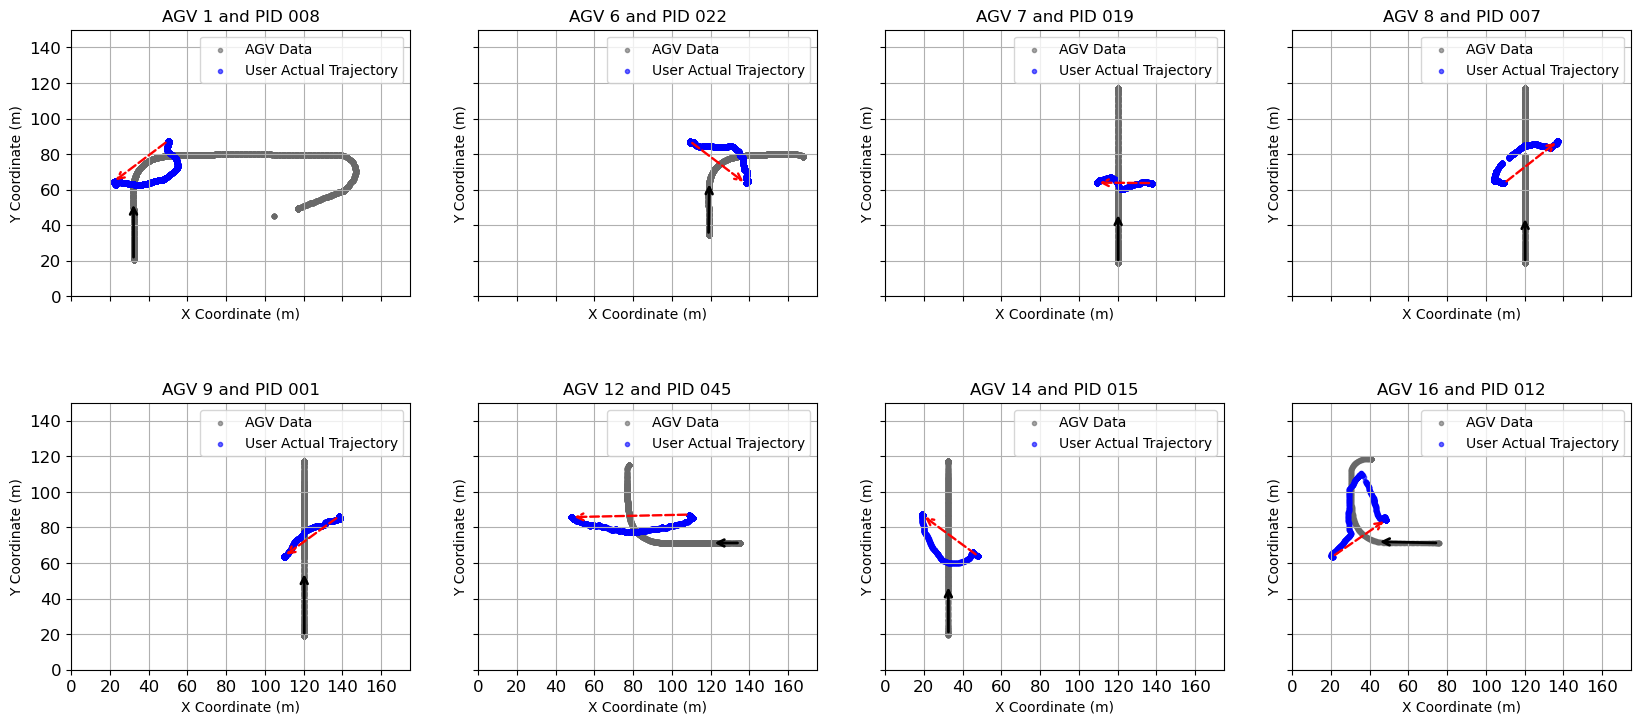

In [38]:
import matplotlib.pyplot as plt
import numpy as np

selected_agv_names = [1, 6, 7, 8, 9, 12, 14, 16]

selected_pids = ['008', '022', '019', '007', '001', '045', '015', '012']
# Set global font properties
plt.rcParams.update({
    'font.size': 12,        # Set global font size
})

# Create subplots: 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)

# Loop through each selected AGV and its corresponding PID
for i, (agv_name, pid_name) in enumerate(zip(selected_agv_names, selected_pids)):
    
    ax = axes[int(i / 4), int(i % 4)]  
    
    # Filter data for the current AGV and PID
    filtered_data = study_data_processed[
        (study_data_processed['AGVname'] == agv_name) & 
        (study_data_processed['PID'] == pid_name) & 
        (study_data_processed['DRate'] == 'High')
    ]

    # Scatter plot for AGV_X and AGV_Y
    scatter1 = ax.scatter(
        filtered_data['AGV_X'] / 100, filtered_data['AGV_Y'] / 100, 
        c='dimgray', marker='.', alpha=0.6, label='AGV Data'
    )

    # Scatter plot for User_X and User_Y
    scatter2 = ax.scatter(
        filtered_data['User_X'] / 100, filtered_data['User_Y'] / 100, 
        c='blue', marker='.', alpha=0.6, label='User Actual Trajectory'
    )

    # Draw expected user trajectory if there are points
    num_points = len(filtered_data)
    if num_points > 0:
        User_X0 = filtered_data['User_X'].iloc[0] / 100
        User_Y0 = filtered_data['User_Y'].iloc[0] / 100
        User_Xn = filtered_data['User_X'].iloc[-1] / 100
        User_Yn = filtered_data['User_Y'].iloc[-1] / 100
    
        # Plot the expected user trajectory as an arrow
        ax.annotate(
            '',  # No text
            xy=(User_Xn, User_Yn),  # End point of the arrow
            xytext=(User_X0, User_Y0),  # Start point of the arrow
            arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', linewidth=1.7,  linestyle='--'),
            label='User Expected Trajectory'
        )

    # Draw the AGV trajectory arrow if there are points
    if num_points > 1:  # Ensure there are at least two points to draw a direction
        # Get the last two AGV coordinates to compute the direction
        AGV_Xn_1 = filtered_data['AGV_X'].iloc[0] / 100
        AGV_Yn_1 = filtered_data['AGV_Y'].iloc[0] / 100
        AGV_Xn = filtered_data['AGV_X'].iloc[75] / 100
        AGV_Yn = filtered_data['AGV_Y'].iloc[75] / 100
    
        # Add an arrow at the last AGV point to show the direction of movement
        ax.annotate(
            '',  # No text
            xy=(AGV_Xn, AGV_Yn),  # End point of the arrow
            xytext=(AGV_Xn_1, AGV_Yn_1),  # Start point of the arrow
            arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2)
        )

    # Set labels, title, grid, and legend with customized font sizes
    ax.set_xlabel(f'X Coordinate (m)', fontsize=10)
    ax.set_ylabel(f'Y Coordinate (m)', fontsize=10)
    ax.set_title(f'AGV {agv_name} and PID {pid_name}', fontsize=12)
    ax.grid(True)
    ax.legend(fontsize=10)

    # Set limits for X and Y axes
    ax.set_xlim(0, 175)
    ax.set_ylim(0, 150)

    # Set x and y axis ticks with a step of 10
    ax.set_xticks(np.arange(0, 180, 20))
    ax.set_yticks(np.arange(0, 160, 20))

# Adjust subplot spacing to prevent overlap
plt.subplots_adjust(left=0.1, right=0.88, top=0.9, bottom=0.1, hspace=0.4)

# Define the filename using f-string or other appropriate method
filename = f"why_frechet_distance.png"

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi = 400, format='png')

# Show the plot
plt.show()

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\1195411350.py:80: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((User_X_min, User_Y_min), radius=1, color='red', alpha=0.6, lw=2, edgecolor='darkred', linestyle='--')
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\1195411350.py:83: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((User_X_min, User_Y_min), radius=3, color='orange', alpha=0.6, lw=2, edgecolor='red', linestyle='--')
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\1195411350.py:86: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((User_X_min, User_Y_min), radius=5, color='yellow', alpha=0.6, lw=2, edgecolor='orange', linestyle='--')
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\1195411350.py:94: UserWarning: Legend does not support handles for Annotation ins

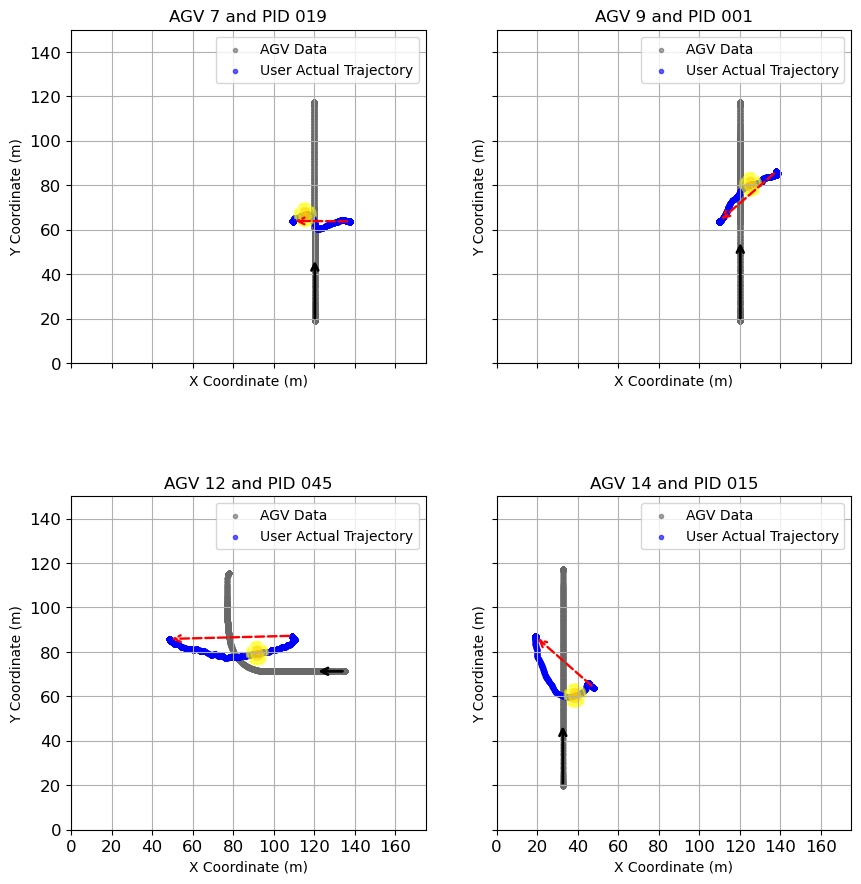

In [58]:
import matplotlib.pyplot as plt
import numpy as np

selected_agv_names = [7, 9, 12, 14]

selected_pids = ['019', '001', '045', '015']

# Set global font properties
plt.rcParams.update({
    'font.size': 12,  # Set global font size
})

# Create subplots: 2 rows and 4 columns
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

# Loop through each selected AGV and its corresponding PID
for i, (agv_name, pid_name) in enumerate(zip(selected_agv_names, selected_pids)):
    
    ax = axes[int(i / 2), int(i % 2)]  
    
    # Filter data for the current AGV and PID
    filtered_data = study_data_processed[
        (study_data_processed['AGVname'] == agv_name) & 
        (study_data_processed['PID'] == pid_name) & 
        (study_data_processed['DRate'] == 'High')
    ]

    # Scatter plot for AGV_X and AGV_Y
    scatter1 = ax.scatter(
        filtered_data['AGV_X'] / 100, filtered_data['AGV_Y'] / 100, 
        c='dimgray', marker='.', alpha=0.6, label='AGV Data'
    )

    # Scatter plot for User_X and User_Y
    scatter2 = ax.scatter(
        filtered_data['User_X'] / 100, filtered_data['User_Y'] / 100, 
        c='blue', marker='.', alpha=0.6, label='User Actual Trajectory'
    )

    # Draw expected user trajectory if there are points
    num_points = len(filtered_data)
    if num_points > 0:
        User_X0 = filtered_data['User_X'].iloc[0] / 100
        User_Y0 = filtered_data['User_Y'].iloc[0] / 100
        User_Xn = filtered_data['User_X'].iloc[-1] / 100
        User_Yn = filtered_data['User_Y'].iloc[-1] / 100
    
        # Plot the expected user trajectory as an arrow
        ax.annotate(
            '',  # No text
            xy=(User_Xn, User_Yn),  # End point of the arrow
            xytext=(User_X0, User_Y0),  # Start point of the arrow
            arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', linewidth=1.7, linestyle='--'),
            label='User Expected Trajectory'
        )

    # Draw the AGV trajectory arrow if there are points
    if num_points > 1:  # Ensure there are at least two points to draw a direction
        # Get the last two AGV coordinates to compute the direction
        AGV_Xn_1 = filtered_data['AGV_X'].iloc[0] / 100
        AGV_Yn_1 = filtered_data['AGV_Y'].iloc[0] / 100
        AGV_Xn = filtered_data['AGV_X'].iloc[75] / 100
        AGV_Yn = filtered_data['AGV_Y'].iloc[75] / 100
    
        # Add an arrow at the last AGV point to show the direction of movement
        ax.annotate(
            '',  # No text
            xy=(AGV_Xn, AGV_Yn),  # End point of the arrow
            xytext=(AGV_Xn_1, AGV_Yn_1),  # Start point of the arrow
            arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2)
        )

    # Detect the minimum AGV_User_Distance and the corresponding User_X and User_Y
    if num_points > 0:
        min_distance_idx = filtered_data['AGV_User_distance'].idxmin()
        User_X_min = filtered_data['User_X'].loc[min_distance_idx] / 100
        User_Y_min = filtered_data['User_Y'].loc[min_distance_idx] / 100

        # Add a circle at the (User_X_min, User_Y_min) position
        circle = plt.Circle((User_X_min, User_Y_min), radius=1, color='red', alpha=0.6, lw=2, edgecolor='darkred', linestyle='--')
        ax.add_patch(circle)
        # Add a circle at the (User_X_min, User_Y_min) position
        circle = plt.Circle((User_X_min, User_Y_min), radius=3, color='orange', alpha=0.6, lw=2, edgecolor='red', linestyle='--')
        ax.add_patch(circle)
        # Add a circle at the (User_X_min, User_Y_min) position
        circle = plt.Circle((User_X_min, User_Y_min), radius=5, color='yellow', alpha=0.6, lw=2, edgecolor='orange', linestyle='--')
        ax.add_patch(circle)

    # Set labels, title, grid, and legend with customized font sizes
    ax.set_xlabel(f'X Coordinate (m)', fontsize=10)
    ax.set_ylabel(f'Y Coordinate (m)', fontsize=10)
    ax.set_title(f'AGV {agv_name} and PID {pid_name}', fontsize=12)
    ax.grid(True)
    ax.legend(fontsize=10)

    # Set limits for X and Y axes
    ax.set_xlim(0, 175)
    ax.set_ylim(0, 150)

    # Set x and y axis ticks with a step of 10
    ax.set_xticks(np.arange(0, 180, 20))
    ax.set_yticks(np.arange(0, 160, 20))

# Adjust subplot spacing to prevent overlap
plt.subplots_adjust(left=0.1, right=0.88, top=0.9, bottom=0.1, hspace=0.4)

# Define the filename using f-string or other appropriate method
filename = f"why_frechet_distance.png"

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi=400, format='png')

# Show the plot
plt.show()

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\145306118.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  agv_colors = cm.get_cmap('coolwarm')(agv_speed)  # Map AGV speed directly to the colormap
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\145306118.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  user_colors = cm.get_cmap('coolwarm')(user_speed)  # Map User speed directly to the colormap
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_12824\145306118.py:80: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((User_X_min, User_Y_min), radius=10, color='blue', alpha=0

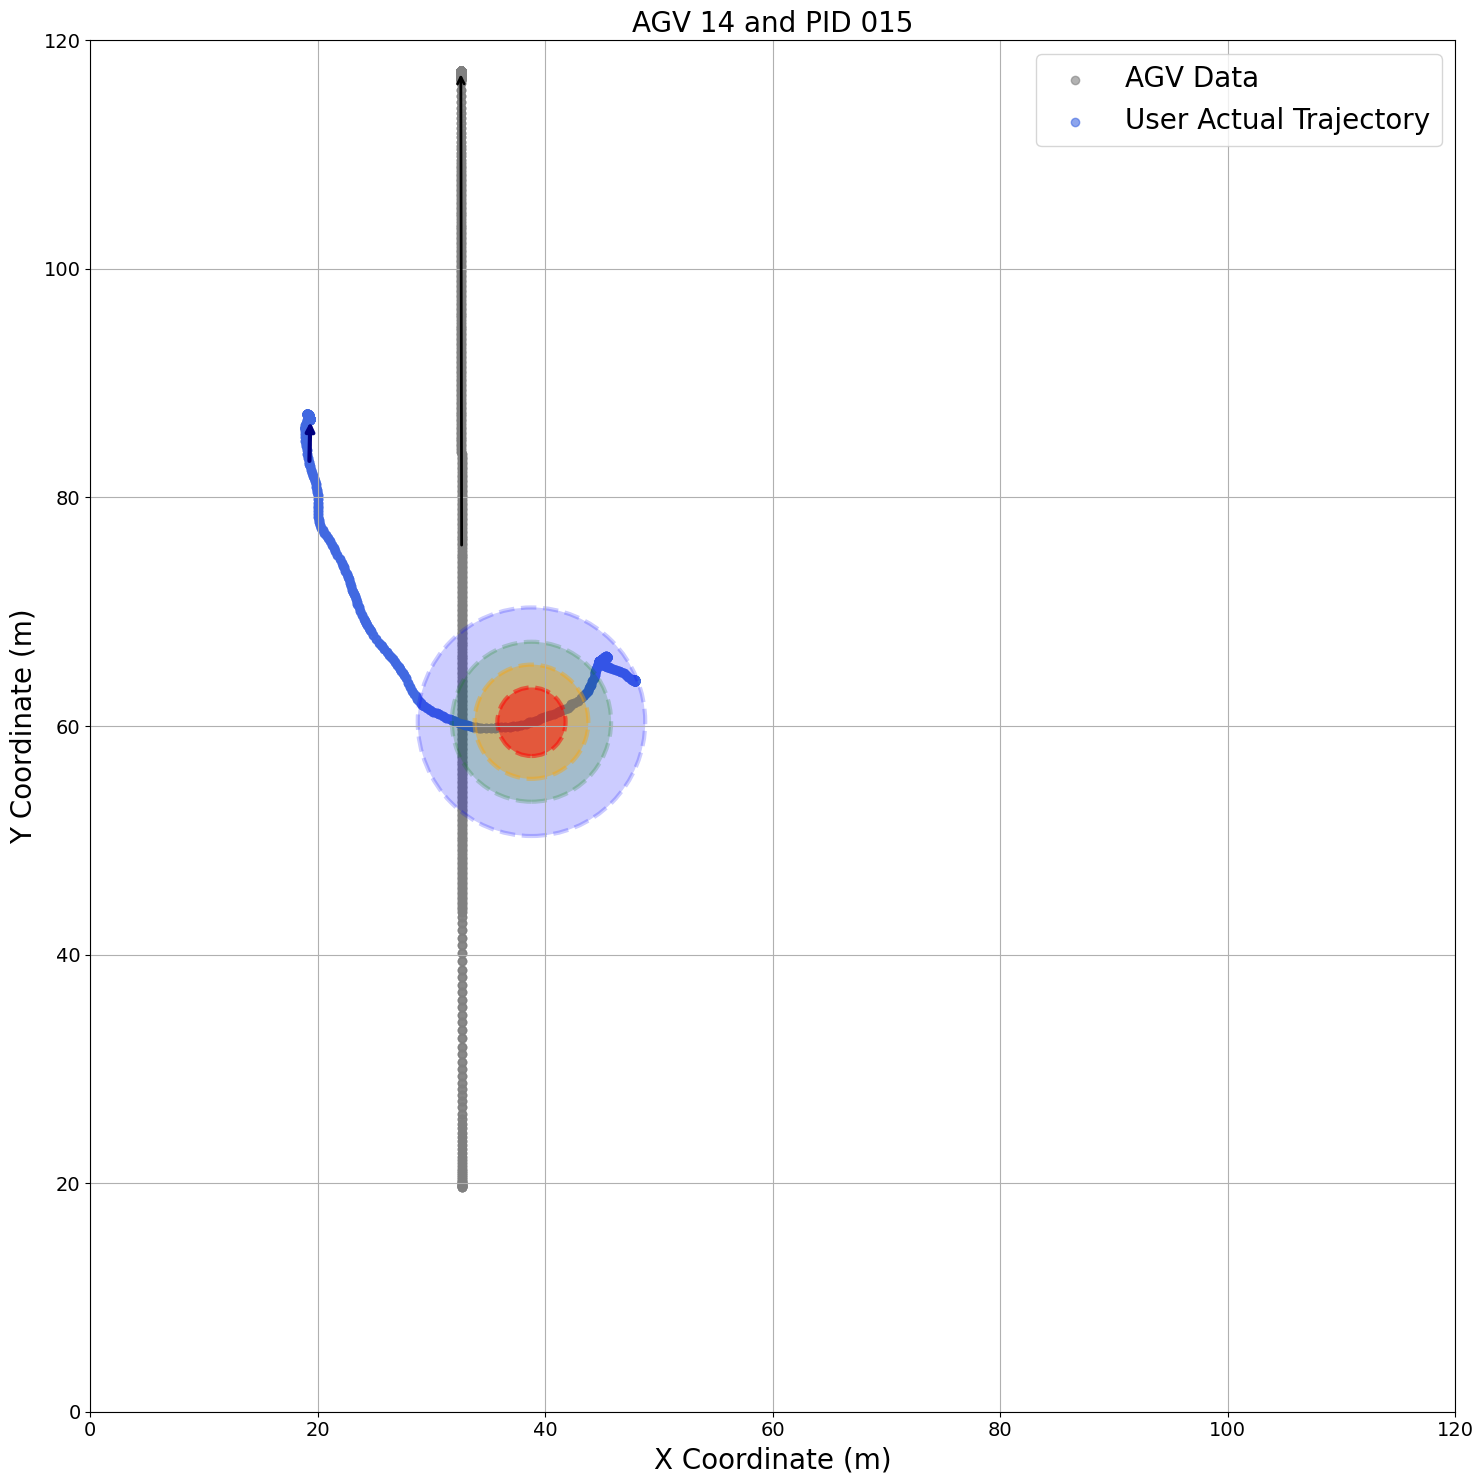

In [117]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Assuming study_data_processed is already defined and contains the necessary columns
# Get unique AGV names and PIDs
agv_name = 14
pid_name = '015'

# Create the plot for a single AGV and PID
fig, ax = plt.subplots(figsize=(15, 15))

# Filter data for the current AGV and PID, and DRate = 'High'
filtered_data = study_data_processed[
    (study_data_processed['AGVname'] == agv_name) & 
    (study_data_processed['PID'] == pid_name) & 
    (study_data_processed['DRate'] == 'High')
]

# Get the raw speed values for AGV and User
agv_speed = filtered_data['AGV_Relative_Speed']
user_speed = filtered_data['User_Relative_Speed']

# Create color maps for AGV and User speed without normalization
agv_colors = cm.get_cmap('coolwarm')(agv_speed)  # Map AGV speed directly to the colormap
user_colors = cm.get_cmap('coolwarm')(user_speed)  # Map User speed directly to the colormap

# Scatter plot for AGV_X and AGV_Y with colors based on AGV speed
scatter1 = ax.scatter(
    filtered_data['AGV_X'] / 100, filtered_data['AGV_Y'] / 100, 
    c='gray', marker='o', alpha=0.6, label='AGV Data'
)

# Scatter plot for User_X and User_Y with colors based on User speed
scatter2 = ax.scatter(
    filtered_data['User_X'] / 100, filtered_data['User_Y'] / 100, 
    c='royalblue', marker='o', alpha=0.6, label='User Actual Trajectory'
)

# Draw expected user trajectory if there are points
num_points = len(filtered_data)
if num_points > 0:
    # Get first and last user coordinates
    User_X0 = filtered_data['User_X'].iloc[275] / 100
    User_Y0 = filtered_data['User_Y'].iloc[275] / 100
    User_Xn = filtered_data['User_X'].iloc[-1] / 100
    User_Yn = filtered_data['User_Y'].iloc[-1] / 100
    
    # Plot the expected user trajectory as an arrow
    ax.annotate(
        '',  # No text
        xy=(User_Xn, User_Yn),  # End point of the arrow
        xytext=(User_X0, User_Y0),  # Start point of the arrow
        arrowprops=dict(facecolor='navy', edgecolor='navy', arrowstyle='-|>', linewidth=3),
        label='User Expected Trajectory'
    )

# Draw the AGV trajectory arrow if there are points
if num_points > 1:  # Ensure there are at least two points to draw a direction
    # Get the last two AGV coordinates to compute the direction
    AGV_Xn_1 = filtered_data['AGV_X'].iloc[200] / 100
    AGV_Yn_1 = filtered_data['AGV_Y'].iloc[200] / 100
    AGV_Xn = filtered_data['AGV_X'].iloc[-1] / 100
    AGV_Yn = filtered_data['AGV_Y'].iloc[-1] / 100

    # Add an arrow at the last AGV point to show the direction of movement
    ax.annotate(
        '',  # No text
        xy=(AGV_Xn, AGV_Yn),  # End point of the arrow
        xytext=(AGV_Xn_1, AGV_Yn_1),  # Start point of the arrow
        arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2)
    )

# Detect the minimum AGV_User_Distance and the corresponding User_X and User_Y
    if num_points > 0:
        min_distance_idx = filtered_data['AGV_User_distance'].idxmin()
        User_X_min = filtered_data['User_X'].loc[min_distance_idx] / 100
        User_Y_min = filtered_data['User_Y'].loc[min_distance_idx] / 100
        # Add a circle at the (User_X_min, User_Y_min) position
        circle = plt.Circle((User_X_min, User_Y_min), radius=10, color='blue', alpha=0.2, lw=3, edgecolor='orange', linestyle='--')
        ax.add_patch(circle)
        # Add a circle at the (User_X_min, User_Y_min) position
        circle = plt.Circle((User_X_min, User_Y_min), radius=7, color='green', alpha=0.2, lw=3, edgecolor='orange', linestyle='--')
        ax.add_patch(circle)
        # Add a circle at the (User_X_min, User_Y_min) position
        circle = plt.Circle((User_X_min, User_Y_min), radius=5, color='orange', alpha=0.4, lw=3, edgecolor='red', linestyle='--')
        ax.add_patch(circle)
        # Add a circle at the (User_X_min, User_Y_min) position
        circle = plt.Circle((User_X_min, User_Y_min), radius=3, color='red', alpha=0.5, lw=3, edgecolor='darkred', linestyle='--')
        ax.add_patch(circle)
             

# Plot labels and grid
ax.set_xlabel(f'X Coordinate (m)', fontsize=20)
ax.set_ylabel(f'Y Coordinate (m)', fontsize=20)
ax.set_title(f'AGV {agv_name} and PID {pid_name}', fontsize=20)
ax.grid(True)
ax.legend(fontsize=20)

# Set limits for X and Y axes (optional)
ax.set_xlim(0, 120)
ax.set_ylim(0, 120)

# Optionally, you can adjust grid (tick) font size specifically:
ax.tick_params(axis='both', labelsize=14)

# Adjust layout
plt.tight_layout()

# Define the filename using f-string or other appropriate method
filename = f"different_frechet_distance.png"

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi=400, format='png')

# Show the plot
plt.show()